# Kidney lncRNA Pipeline

### Setting up environment

In [2]:
# libraries
import sys
import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = "notebook"
import nsforest as ns
from nsforest import utils
import celltypist as ct

/opt/miniconda3/envs/nsforest/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [3]:
# configs
code_folder = "/Users/vbecker/Desktop/NSForest-ncRNA"
sys.path.insert(0, os.path.abspath(code_folder))

data_folder = "../beckersv_data/"
file = data_folder + "nsf_hca_kidney.h5ad"

output_folder = "../beckersv_output/"

annotate_file = "../gencode_annotation/gencode_annotation/gencode.v47.annotation_txLength.csv"

to_downsample = True
to_downsample_num = 100000

seed = 1990

### Data Exploration

#### Loading AnnData file

In [4]:
adata_raw = sc.read_h5ad(file)
adata_raw

AnnData object with n_obs × n_vars = 304652 × 33140
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicit

#### Looking at sample labels

In [5]:
adata_raw.obs_names # sample names

Index(['KB1_AAACCCAAGCCGATAG', 'KB1_AAACCCAAGGAACTAT', 'KB1_AAACCCAAGGTTATAG',
       'KB1_AAACCCAGTAATGCGG', 'KB1_AAACCCAGTACTAACC', 'KB1_AAACCCAGTGCGAACA',
       'KB1_AAACCCAGTTGTGCAT', 'KB1_AAACCCATCAGGTGTT', 'KB1_AAACCCATCTTAAGGC',
       'KB1_AAACGAAAGAGTCAAT',
       ...
       'LDSample1162EO2_TTTGACTGTATCGTGT-1',
       'LDSample1162EO2_TTTGACTGTCGCCACA-1',
       'LDSample1162EO2_TTTGATCAGTTGCCTA-1',
       'LDSample1162EO2_TTTGATCGTGAGTAGC-1',
       'LDSample1162EO2_TTTGATCGTGTGGTCC-1',
       'LDSample1162EO2_TTTGATCTCTCCTGCA-1',
       'LDSample1162EO2_TTTGGAGAGCAGGCAT-1',
       'LDSample1162EO2_TTTGGAGAGTGCTCGC-1',
       'LDSample1162EO2_TTTGGAGGTGATACTC-1',
       'LDSample1162EO2_TTTGGTTCAGTAGAAT-1'],
      dtype='object', name='index', length=304652)

In [6]:
adata_raw.obs.columns # sample metadata

Index(['nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt',
       'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score',
       'matrisome.score', 'collagen.score', 'glycoprotein.score',
       'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen',
       'condition.long', 'condition.l1', 'condition.l2', 'donor_id',
       'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla',
       'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed',
       'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1',
       'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI',
       'diabetes_history', 'hypertension', 'tissue_ontology_term_id',
       'assay_ontology_term_id', 'cell_type_ontology_term_id',
       'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type',
       'assay', 'diseas

#### Looking at genes

**Note:** `adata.var_names` must be unique. If there is a problem, usually it can be solved by assigning `adata.var.index = adata.var["ensembl_id"]`. 

In [7]:
adata_raw.var_names # gene names

Index(['ENSG00000121410', 'ENSG00000268895', 'ENSG00000148584',
       'ENSG00000175899', 'ENSG00000245105', 'ENSG00000166535',
       'ENSG00000256661', 'ENSG00000184389', 'ENSG00000128274',
       'ENSG00000118017',
       ...
       'ENSG00000207468', 'ENSG00000201821', 'ENSG00000199477',
       'ENSG00000222489', 'ENSG00000242737', 'ENSG00000279622',
       'ENSG00000261499', 'ENSG00000279570', 'ENSG00000249263',
       'ENSG00000253460'],
      dtype='object', length=33140)

In [8]:
adata_raw.var.columns # gene metadata
adata_raw.var["feature_type"].value_counts().head(5)

feature_type
protein_coding                        18722
lncRNA                                11509
processed_pseudogene                   1084
transcribed_unprocessed_pseudogene      532
TEC                                     430
Name: count, dtype: int64

### Downsampling and Subsetting

#### Defining `cluster_header` as cell type annotation and gene comparison for subset.

**Note:** Some datasets have multiple annotations per sample (ex. "broad_cell_type" and "granular_cell_type"). NS-Forest can be run on multiple `cluster_header`'s. Combining the parent and child markers may improve classification results. 

In [9]:
cluster_header = "cell_type"
subset_col = "feature_type"
subset_gene = "lncRNA"

#### Checking cell annotation sizes 

**Note:** Some datasets are too large and need to be downsampled to be run through the pipeline. When downsampling, be sure to have all the granular cluster annotations represented. 

In [10]:
pd.DataFrame(adata_raw.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,epithelial cell of proximal tubule,76031
1,kidney loop of Henle thick ascending limb epit...,66257
2,endothelial cell,25175
3,kidney collecting duct principal cell,23239
4,kidney collecting duct intercalated cell,18001
5,kidney interstitial fibroblast,16548
6,kidney connecting tubule epithelial cell,13245
7,kidney distal convoluted tubule epithelial cell,13216
8,kidney loop of Henle thin descending limb epit...,9786
9,T cell,7118


#### (Optional) Downsampling

In [11]:
if to_downsample:
    adata = ct.samples.downsample_adata(adata_raw, mode = "total", n_cells = to_downsample_num, by = cluster_header,
                                        random_state = seed, return_index = False)
else:
    adata = adata_raw

In [12]:
pd.DataFrame(adata.obs[cluster_header].value_counts()).reset_index()

,cell_type,count
0,epithelial cell of proximal tubule,25098
1,kidney loop of Henle thick ascending limb epit...,21498
2,endothelial cell,8201
3,kidney collecting duct principal cell,7598
4,kidney collecting duct intercalated cell,5948
5,kidney interstitial fibroblast,5459
6,kidney connecting tubule epithelial cell,4353
7,kidney distal convoluted tubule epithelial cell,4350
8,kidney loop of Henle thin descending limb epit...,3266
9,T cell,2280


#### Subsetting based on gene type.

In [13]:
# Keep only lncRNA genes
adata_subset = adata[:, adata.var[subset_col] == subset_gene].copy()

print(adata.shape)
print(adata_subset.shape)

# Save
filename = file.replace(".h5ad", f"_subset_{subset_gene}.h5ad")
print(f"Saving subset anndata object as...\n{filename}")
adata_subset.write_h5ad(filename)

(100000, 33140)
(100000, 11509)
Saving subset anndata object as...
../beckersv_data/nsf_hca_kidney_subset_lncRNA.h5ad


### Preprocessing

#### Generating scanpy dendrograms

**Note:** Only run if there is no pre-defined dendrogram order. This step can still be run with no effects, but the runtime may increase. 

Dendrogram order is stored in `adata.uns["dendrogram_cluster"]["categories_ordered"]`. 

Saving dendrogram as...
../beckersv_output/_cell_type.png


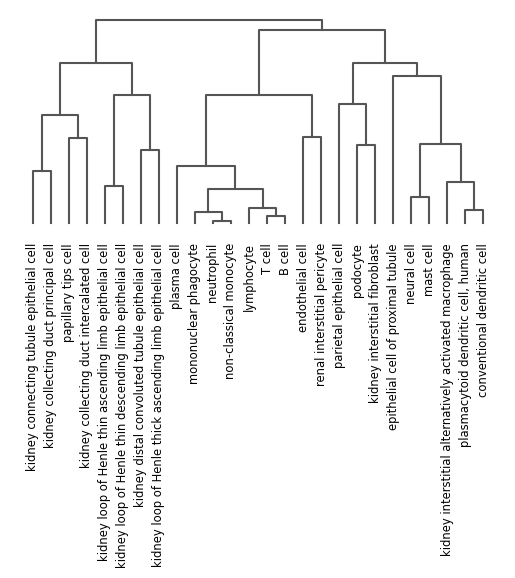

In [14]:
# full adata
if not adata.obsm or "X_pca" not in adata.obsm:
    sc.pp.pca(adata, random_state=seed)

ns.pp.dendrogram(adata, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

Saving dendrogram as...
../beckersv_output/_cell_type.png


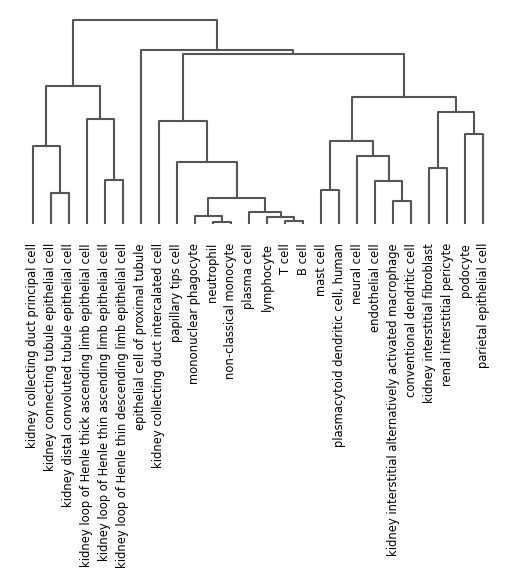

In [15]:
# subset adata
if not adata_subset.obsm or "X_pca" not in adata_subset.obsm:
    sc.pp.pca(adata_subset, random_state=seed)

ns.pp.dendrogram(adata_subset, cluster_header, save = True, output_folder = output_folder, outputfilename_suffix = cluster_header)

#### Calculating cluster medians per gene

Run `ns.pp.prep_medians` before running NS-Forest.

**Note:** Do **not** run if evaluating marker lists. Do **not** run when generating scanpy plots (e.g. dot plot, violin plot, matrix plot). 

In [16]:
# full adata
adata = ns.pp.prep_medians(adata, cluster_header)
adata.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 26/26 [00:21<00:00,  1.19it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.012
std: 0.148
Only positive genes selected. 1933 positive genes out of 33140 total genes
--- 22.96658682823181 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000175899,0.0,0.0,0.0,1.413055,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,1.114692
ENSG00000115977,0.0,0.0,0.0,0.000000,0.0,0.000000,1.325979,0.843635,0.521632,0.0,...,0.0,0.0,0.0,0.0,0.588177,0.0,0.0,0.0,0.0,0.000000
ENSG00000198691,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
ENSG00000154265,0.0,0.0,0.0,0.000000,0.0,0.884318,0.000000,0.000000,1.148271,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000
ENSG00000125257,0.0,0.0,0.0,0.000000,0.0,0.906396,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000


In [17]:
# subset adata
adata_subset = ns.pp.prep_medians(adata_subset, cluster_header)
adata_subset.varm[f"medians_{cluster_header}"].head()

Calculating medians per cluster: 100%|██████████| 26/26 [00:07<00:00,  3.28it/s]


Saving medians as adata.varm.medians_cell_type
median: 0.0
mean: 0.001
std: 0.068
Only positive genes selected. 45 positive genes out of 11509 total genes
--- 8.399025917053223 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000231312,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
ENSG00000236283,0.0,0.0,0.000000,0.0,0.0,1.491415,2.588741,2.960015,2.668397,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0
ENSG00000225885,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.009196,0.000000,0.0
ENSG00000230027,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,1.635208,0.0
ENSG00000231873,0.0,0.0,1.654263,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0


#### Calculating binary scores per gene per cluster

Run `ns.pp.prep_binary_scores` before running NS-Forest. Do not need to run if evaluating marker lists. Do not need to run when generating scanpy plots. 

In [18]:
# full adata
adata = ns.pp.prep_binary_scores(adata, cluster_header)
adata.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 26/26 [00:02<00:00, 12.13it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.108
std: 0.278
--- 2.1527838706970215 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000175899,0.0,0.0,0.0,0.968446,0.0,0.000000,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.96
ENSG00000115977,0.0,0.0,0.0,0.000000,0.0,0.000000,0.907058,0.86738,0.840000,0.0,...,0.0,0.0,0.0,0.0,0.844526,0.0,0.0,0.0,0.0,0.00
ENSG00000198691,0.0,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00
ENSG00000154265,0.0,0.0,0.0,0.000000,0.0,0.960000,0.000000,0.00000,0.969195,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00
ENSG00000125257,0.0,0.0,0.0,0.000000,0.0,0.939698,0.000000,0.00000,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.00


In [19]:
# subset adata
adata_subset = ns.pp.prep_binary_scores(adata_subset, cluster_header)
adata_subset.varm[f"binary_scores_{cluster_header}"].head()

Calculating binary scores per cluster: 100%|██████████| 26/26 [00:00<00:00, 355.82it/s]

Saving binary scores as adata.varm.binary_scores_cell_type
median: 0.0
mean: 0.086
std: 0.254
--- 0.07631087303161621 seconds ---


,B cell,T cell,conventional dendritic cell,endothelial cell,epithelial cell of proximal tubule,kidney collecting duct intercalated cell,kidney collecting duct principal cell,kidney connecting tubule epithelial cell,kidney distal convoluted tubule epithelial cell,kidney interstitial alternatively activated macrophage,...,mononuclear phagocyte,neural cell,neutrophil,non-classical monocyte,papillary tips cell,parietal epithelial cell,plasma cell,"plasmacytoid dendritic cell, human",podocyte,renal interstitial pericyte
ENSG00000231312,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000236283,0.0,0.0,0.0,0.0,0.0,0.803497,0.847739,0.865761,0.85109,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ENSG00000225885,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ENSG00000230027,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ENSG00000231873,0.0,0.0,1.0,0.0,0.0,0.000000,0.000000,0.000000,0.00000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#### Saving preprocessed AnnData as new h5ad

In [20]:
# full adata
filename = file.replace(".h5ad", "_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../beckersv_data/nsf_hca_kidney_preprocessed.h5ad


AnnData object with n_obs × n_vars = 100000 × 1933
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity

In [21]:
# subset adata
filename = file.replace(".h5ad", f"_subset_{subset_gene}_preprocessed.h5ad")
print(f"Saving new anndata object as...\n{filename}")
adata.write_h5ad(filename)
adata

Saving new anndata object as...
../beckersv_data/nsf_hca_kidney_subset_lncRNA_preprocessed.h5ad


AnnData object with n_obs × n_vars = 100000 × 1933
    obs: 'nCount_RNA', 'nFeature_RNA', 'library', 'percent.er', 'percent.mt', 'degen.score', 'aEpi.score', 'aStr.score', 'cyc.score', 'matrisome.score', 'collagen.score', 'glycoprotein.score', 'proteoglycan.score', 'S.Score', 'G2M.Score', 'experiment', 'specimen', 'condition.long', 'condition.l1', 'condition.l2', 'donor_id', 'region.l1', 'region.l2', 'percent.cortex', 'percent.medulla', 'sample_tissue_type', 'id', 'pagoda_k100_infomap_coembed', 'subclass.full', 'subclass.l3', 'subclass.l2', 'subclass.l1', 'state.l2', 'state', 'class', 'structure', 'disease_ontology_term_id', 'sex_ontology_term_id', 'development_stage_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'eGFR', 'BMI', 'diabetes_history', 'hypertension', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity

### Running NS-Forest

**Note:** Do not run NS-Forest if only evaluating input marker lists. 

In [ ]:
# full adata
outputfilename_prefix = cluster_header
results = ns.nsforesting.NSForest(adata, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
results

In [ ]:
# subset adata
outputfilename_prefix_subset = cluster_header + "_subset_" + subset_gene
results_subset = ns.nsforesting.NSForest(adata_subset, cluster_header, save_supplementary = True, save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)
results_subset

### Visualization (Preprocessing)

In [ ]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

In [ ]:
ns.pp.plot_varm(adata, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"medians_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

In [ ]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", nonzero = True, save = True, output_folder = output_folder)

In [ ]:
ns.pp.plot_varm(adata, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)
ns.pp.plot_varm(adata_subset, f"binary_scores_{cluster_header}", scale = "log", save = True, output_folder = output_folder)

### Visualization (Results): Plotting scanpy dot plot, violin plot, matrix plot for NS-Forest markers

**Note:** Assign pre-defined dendrogram order here **or** use `adata.uns["dendrogram_" + cluster_header]["categories_ordered"]`. 

In [ ]:
to_plot = results.copy()
to_plot_subset = results_subset.copy()

In [ ]:
# full adata
dendrogram = [] # custom dendrogram order
dendrogram = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot["clusterName"] = to_plot["clusterName"].astype("category")
to_plot["clusterName"] = to_plot["clusterName"].cat.set_categories(dendrogram)
to_plot = to_plot.sort_values("clusterName")
to_plot = to_plot.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# subset adata
dendrogram_subset = [] # custom dendrogram order
dendrogram_subset = list(adata.uns["dendrogram_" + cluster_header]["categories_ordered"])
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].astype("category")
to_plot_subset["clusterName"] = to_plot_subset["clusterName"].cat.set_categories(dendrogram_subset)
to_plot_subset = to_plot_subset.sort_values("clusterName")
to_plot_subset = to_plot_subset.rename(columns = {"NSForest_markers": "markers"})

In [ ]:
# full adata
markers_dict = dict(zip(to_plot["clusterName"], to_plot["markers"]))
markers_dict

In [ ]:
# subset adata
markers_dict_subset = dict(zip(to_plot_subset["clusterName"], to_plot_subset["markers"]))
markers_dict_subset

In [ ]:
ns.pl.dotplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.dotplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
ns.pl.stackedviolin(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.stackedviolin(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

In [ ]:
ns.pl.matrixplot(adata, markers_dict, cluster_header, dendrogram = dendrogram, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix)
ns.pl.matrixplot(adata_subset, markers_dict_subset, cluster_header, dendrogram = dendrogram_subset, save = True, output_folder = output_folder, outputfilename_suffix = outputfilename_prefix_subset)

#### Plotting classification metrics from NS-Forest results

In [ ]:
ns.pl.boxplot(results, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, ["f_score", "precision", "recall", "onTarget"], save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

#### Plotting individual classification metrics

In [ ]:
ns.pl.boxplot(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.boxplot(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

#### Plotting metrics vs clusterSize

In [ ]:
ns.pl.scatter_w_clusterSize(results, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "f_score", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
ns.pl.scatter_w_clusterSize(results, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "precision", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
ns.pl.scatter_w_clusterSize(results, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "recall", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)

In [ ]:
ns.pl.scatter_w_clusterSize(results, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix)
ns.pl.scatter_w_clusterSize(results_subset, "onTarget", save = True, output_folder = output_folder, outputfilename_prefix = outputfilename_prefix_subset)